[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/experiments/sjepa/gavd5-drift/neurips-brain-body/06_capstone_health_condition_classifiers.ipynb)

# 06. Source-disjoint fold-local readouts and controls

Tune a shallow readout using only training and validation sources, then open the outer-test tensors once. The primary report aggregates sequence probabilities within each source video before scoring, so a long upload is not treated as many independent patients.

**Research use only.** This exploratory dataset-label task is not a diagnostic system or patient-level validation.


In [1]:
from pathlib import Path
import copy
import hashlib
import json
import os
import random
import sys

import numpy as np
import pandas as pd
import torch
from IPython.display import SVG, display


def find_experiment_dir(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "neurips-brain-body").is_dir() and (candidate / "data-gavd").is_dir():
            return candidate
        nested = candidate / "experiments" / "sjepa" / "gavd5-drift"
        if (nested / "neurips-brain-body").is_dir() and (nested / "data-gavd").is_dir():
            return nested
    raise FileNotFoundError("Could not locate experiments/sjepa/gavd5-drift")


EXPERIMENT_DIR = find_experiment_dir()
NOTEBOOK_DIR = EXPERIMENT_DIR / "neurips-brain-body"


# Use the same experiment-level configuration contract as notebooks 01-02.
# Existing process variables win, so CI and explicit shell overrides remain
# authoritative while an interactive Jupyter kernel still sees `.env`.
try:
    from dotenv import load_dotenv
    load_dotenv(EXPERIMENT_DIR / ".env", override=False)
except ImportError:
    pass
MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be 'smoke' or 'real'")

ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", EXPERIMENT_DIR / "work" / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
PROTOCOL_DIR = ARTIFACT_DIR / "evaluation_protocol"
POSE_DIR = ARTIFACT_DIR / "poses"
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
for folder in (ARTIFACT_DIR, CHECKPOINT_DIR):
    folder.mkdir(parents=True, exist_ok=True)


def truthy(name, default="0"):
    return os.getenv(name, default).strip().lower() in {"1", "true", "yes", "on"}


def show_tutorial_svg(filename):
    path = EXPERIMENT_DIR / "images" / filename
    if not path.is_file():
        raise FileNotFoundError(path)
    display(SVG(filename=str(path)))


OUTER_FOLD = int(os.getenv("SJEPA_OUTER_FOLD", "0"))
MODEL_SEED = int(os.getenv("SJEPA_MODEL_SEED", "42"))
if OUTER_FOLD not in range(5):
    raise ValueError("SJEPA_OUTER_FOLD must be one of 0, 1, 2, 3, 4")
random.seed(MODEL_SEED)
np.random.seed(MODEL_SEED)
torch.manual_seed(MODEL_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print({
    "mode": MODE,
    "outer_fold": OUTER_FOLD,
    "model_seed": MODEL_SEED,
    "device": str(DEVICE),
    "artifacts": str(ARTIFACT_DIR),
})


{'mode': 'real', 'outer_fold': 0, 'model_seed': 42, 'device': 'cpu', 'artifacts': 'C:\\Users\\alexm\\dev\\alexpose\\experiments\\sjepa\\gavd5-drift\\work\\artifacts\\real'}


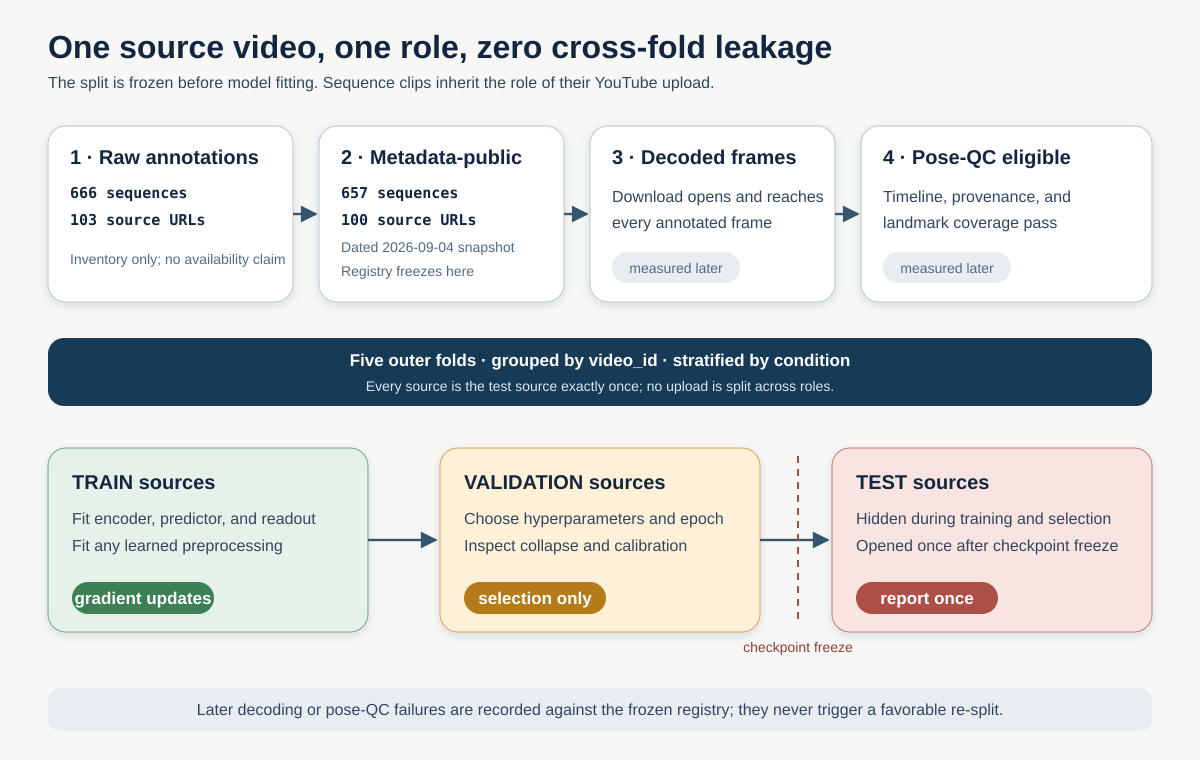

In [2]:
show_tutorial_svg("22_inductive_source_split.svg")


## Archived historical outputs—not executable evidence

The superseded notebook exposed sequence-confounded, encoder-transductive numbers. They are preserved only for provenance and must not be compared as independent-test results:

|Archived lane|Accuracy|Macro-F1|Why it is retired|
|---|---:|---:|---|
|All-96 S-JEPA sequence split|0.724|0.750|16 train/test source overlaps; test rows seen by encoder|
|exp5-compatible S-JEPA 47/21|0.762|0.765|9 train/test source overlaps; test rows seen by encoder|
|exp5 handcrafted 82-feature RF|0.762|0.728|Video-confounded extraction and split|
|Augmented binary grouped stress test|0.787|0.765|Encoder remained transductive; augmentation changed normal only|
|Augmented five-class grouped stress test|0.564|0.495|Encoder remained transductive|

The old missingness-only accuracies were 0.483 (all-96) and 0.286 (exp5). None of these archived values is loaded, recomputed, or used for model selection below.

The fold-local notebook 02 pose-QC ledger is authoritative. Notebook 01's same-named value is only a pending placeholder; it is replaced after fold, manifest-hash, split-hash, and role validation. Pose locations use the explicit `pose_path` namespace so they cannot collide with downloaded-video `path` fields.


In [3]:
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
ROLE_ORDER = ["train", "validation", "test"]


def stable_seed(text):
    return int(hashlib.sha256(str(text).encode("utf-8")).hexdigest()[:8], 16)


def table_sha256(table, columns):
    canonical = table.loc[:, columns].copy().sort_values(columns).reset_index(drop=True)
    payload = canonical.to_csv(index=False, lineterminator="\n").encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def synthetic_metadata(outer_fold=0):
    """Five sources per condition: three train, one validation, one test.

    These rows exercise provenance and isolation. They are not a disease model,
    benchmark sample, or substitute for GAVD.
    """
    rows = []
    test_slot = outer_fold % 5
    validation_slot = (outer_fold + 1) % 5
    for condition in CONDITIONS:
        for source_slot in range(5):
            role = (
                "test" if source_slot == test_slot
                else "validation" if source_slot == validation_slot
                else "train"
            )
            video_id = f"smoke_{condition}_source_{source_slot}"
            for sequence_slot in range(2):
                rows.append({
                    "condition": condition,
                    "video_id": video_id,
                    "sequence_id": f"{video_id}_sequence_{sequence_slot}",
                    "role": role,
                    "pose_qc_eligible": True,
                    "path": "",
                })
    table = pd.DataFrame(rows)
    manifest_sha = table_sha256(table, ["condition", "video_id", "sequence_id"])
    split_sha = table_sha256(table, ["condition", "video_id", "role"])
    return table, {
        "manifest_sha256": manifest_sha,
        "split_sha256": split_sha,
        "split_version": "smoke_source_fixture_v2",
    }


def load_protocol_metadata(outer_fold):
    """Load the frozen registry and fold-specific pose-QC gate.

    This function loads metadata only. Pose tensors are opened later and only for
    the role explicitly requested by the caller.
    """
    if str(NOTEBOOK_DIR) not in sys.path:
        sys.path.insert(0, str(NOTEBOOK_DIR))
    from evaluation_protocol import (
        attach_pose_qc_eligibility,
        expand_split,
        manifest_fingerprint,
        split_fingerprint,
        validate_split_registry,
    )

    manifest_path = PROTOCOL_DIR / "eligible_sequence_manifest.csv"
    registry_path = PROTOCOL_DIR / "source_split_registry.csv"
    contract_path = PROTOCOL_DIR / "source_split_contract.json"
    qc_path = PROTOCOL_DIR / f"pose_qc_eligibility_outer_fold_{outer_fold}.csv"
    for path in (manifest_path, registry_path, contract_path, qc_path):
        if not path.is_file():
            raise FileNotFoundError(
                f"Missing {path}. Real mode requires notebooks 01 and 02 for this fold."
            )

    manifest = pd.read_csv(manifest_path)
    registry = pd.read_csv(registry_path)
    contract = json.loads(contract_path.read_text(encoding="utf-8"))
    validate_split_registry(registry, manifest)
    manifest_sha = manifest_fingerprint(manifest)
    split_sha = split_fingerprint(registry)
    if manifest_sha != contract["manifest_sha256"]:
        raise ValueError("Frozen manifest hash differs from source_split_contract.json")
    if split_sha != contract["split_sha256"]:
        raise ValueError("Frozen registry hash differs from source_split_contract.json")

    split_rows = expand_split(manifest, registry, outer_fold)
    qc = pd.read_csv(qc_path)
    table = attach_pose_qc_eligibility(
        split_rows,
        qc,
        outer_fold=outer_fold,
        manifest_sha256=manifest_sha,
        split_sha256=split_sha,
    )
    table = table.loc[table["pose_qc_eligible"]].copy()
    if table.empty:
        raise RuntimeError("No pose-QC-eligible rows are available for this outer fold")
    return table, {
        "manifest_sha256": manifest_sha,
        "split_sha256": split_sha,
        "split_version": str(registry["split_version"].iloc[0]),
    }


def load_metadata(outer_fold):
    return synthetic_metadata(outer_fold) if MODE == "smoke" else load_protocol_metadata(outer_fold)


def synthetic_gait_sequence(condition, sequence_id, frames=36):
    """Deterministic code-path motion; not a physiological simulation."""
    rng = np.random.default_rng(stable_seed(sequence_id))
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    sequence = np.zeros((frames, 33, 4), dtype=np.float32)
    sequence[..., 3] = 1.0
    base = {
        11: (0.42, 0.28), 12: (0.58, 0.28), 23: (0.45, 0.52), 24: (0.55, 0.52),
        25: (0.44, 0.70), 26: (0.56, 0.70), 27: (0.43, 0.89), 28: (0.57, 0.89),
        29: (0.42, 0.92), 30: (0.58, 0.92), 31: (0.39, 0.94), 32: (0.61, 0.94),
    }
    for joint, (x, y) in base.items():
        sequence[:, joint, 0], sequence[:, joint, 1] = x, y
    amplitude, lift = 0.045, 0.025
    if condition == "parkinsons":
        amplitude, lift = amplitude * 0.55, lift * 0.55
    if condition == "myopathic":
        sequence[:, [11, 12], 0] += 0.025 * np.sin(phase)[:, None]
    for ankle, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and ankle == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            sequence[:, knee, 1] -= 0.04
        sequence[:, ankle, 0] += amplitude * wave
        sequence[:, knee, 0] += 0.4 * amplitude * wave
        sequence[:, foot, 0] += amplitude * wave
        sequence[:, ankle, 1] -= lift * np.maximum(wave, 0.0)
    sequence[..., :3] += rng.normal(0.0, 0.0025, sequence[..., :3].shape)
    missing = rng.random(sequence.shape[:2]) < 0.02
    sequence[missing, 3] = 0.0
    sequence[missing, :3] = np.nan
    return sequence


def load_pose_tensor(row, access_log):
    """Load one eligible pose and record the role-level tensor access."""
    role = str(row["role"])
    if MODE == "smoke":
        sequence = synthetic_gait_sequence(row["condition"], row["sequence_id"])
        path_label = f"synthetic://{row['sequence_id']}"
    else:
        candidate = Path(str(row.get("pose_path", "")))
        fallback = POSE_DIR / row["condition"] / f"{row['sequence_id']}.npz"
        path = candidate if candidate.is_file() else fallback
        if not path.is_file():
            raise FileNotFoundError(f"Pose-QC marked eligible but pose cache is missing: {path}")
        data = np.load(path, allow_pickle=False)
        required = {"sequence", "sequence_id", "video_id", "condition", "manifest_sha256", "split_sha256", "split_roles_json"}
        missing_keys = required.difference(data.files)
        if missing_keys:
            raise ValueError(f"Stale pose cache {path}; missing {sorted(missing_keys)}")
        expected = {
            "sequence_id": str(row["sequence_id"]),
            "video_id": str(row["video_id"]),
            "condition": str(row["condition"]),
            "manifest_sha256": MANIFEST_SHA256,
            "split_sha256": SPLIT_SHA256,
        }
        for key, value in expected.items():
            if str(data[key].item()) != value:
                raise ValueError(f"{path}: {key} does not match frozen protocol")
        role_map = json.loads(str(data["split_roles_json"].item()))
        if role_map.get(str(OUTER_FOLD)) != role:
            raise ValueError(f"{path}: role map does not match outer fold {OUTER_FOLD}")
        sequence = data["sequence"]
        path_label = str(path)
    access_log.append({
        "role": role,
        "video_id": str(row["video_id"]),
        "sequence_id": str(row["sequence_id"]),
        "path": path_label,
    })
    return sequence


In [4]:
import math
from torch import nn
from torch.nn import functional as F


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack([np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])], axis=1)
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(sequence, frames):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T,33,4], got {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    valid = (visibility >= 0.45) & np.isfinite(sequence[..., :3]).all(axis=-1)
    xyz = sequence[..., :3]
    hips = np.nanmean(xyz[:, [23, 24]], axis=1)
    fallback = np.nanmedian(hips, axis=0)
    fallback = np.nan_to_num(fallback, nan=0.0)
    hips = np.where(np.isfinite(hips), hips, fallback)
    xyz = xyz - hips[:, None, :]
    shoulder = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    scale = np.nanmedian(np.maximum(shoulder, hip))
    scale = float(scale) if np.isfinite(scale) and scale > 1e-6 else 1.0
    xyz = np.nan_to_num(xyz / scale, nan=0.0, posinf=0.0, neginf=0.0)
    xyz = temporal_resize(xyz, frames).astype(np.float32)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return xyz, valid


class SkeletonEncoder(nn.Module):
    def __init__(self, frames=32, segment_length=4, embed_dim=32, depth=1, heads=4):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames, self.segment_length = frames, segment_length
        self.segments, self.embed_dim = frames // segment_length, embed_dim
        self.patch = nn.Linear(3, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(33, embed_dim) * 0.02)
        self.mask_token = nn.Parameter(torch.zeros(embed_dim))
        layer = nn.TransformerEncoderLayer(
            embed_dim, heads, embed_dim * 2, dropout=0.0,
            activation="gelu", batch_first=True, norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch = len(x)
        return x.reshape(batch, self.segments, self.segment_length, 33, 3).mean(dim=2)

    def patch_valid(self, valid):
        batch = len(valid)
        return valid.reshape(batch, self.segments, self.segment_length, 33).all(dim=2)

    def forward(self, x, hidden=None):
        patches = self.patchify(x)
        tokens = self.patch(patches)
        if hidden is not None:
            tokens = torch.where(hidden[..., None], self.mask_token, tokens)
        tokens = tokens + self.time_pos[None, :, None, :] + self.joint_pos[None, None, :, :]
        shape = tokens.shape
        tokens = self.blocks(tokens.reshape(shape[0], shape[1] * shape[2], shape[3]))
        return self.norm(tokens).reshape(shape)


class SJEPAProjector(nn.Module):
    def __init__(self, embed_dim=32, project_dim=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(embed_dim, embed_dim), nn.GELU(), nn.Linear(embed_dim, project_dim))

    def forward(self, x):
        return self.net(x)


class SJEPAPredictor(nn.Module):
    def __init__(self, segments, embed_dim=32):
        super().__init__()
        self.position = nn.Parameter(torch.randn(segments, 33, embed_dim) * 0.02)
        self.net = nn.Sequential(nn.Linear(embed_dim, embed_dim * 2), nn.GELU(), nn.Linear(embed_dim * 2, embed_dim))

    def forward(self, context_tokens, visible):
        weight = visible[..., None].float()
        context = (context_tokens * weight).sum((1, 2)) / weight.sum((1, 2)).clamp_min(1.0)
        return self.net(context[:, None, None, :] + self.position[None])


def model_components(config, device=DEVICE):
    online = SkeletonEncoder(**config).to(device)
    target = copy.deepcopy(online).to(device).eval()
    for parameter in target.parameters():
        parameter.requires_grad_(False)
    predictor = SJEPAPredictor(online.segments, config["embed_dim"]).to(device)
    projector = SJEPAProjector(config["embed_dim"], config["embed_dim"]).to(device)
    group_head = nn.Linear(config["embed_dim"], len(CONDITIONS)).to(device)
    return online, target, predictor, projector, group_head


def uniform_target_mask(valid_patch, fraction, generator):
    eligible_joint = torch.zeros(33, dtype=torch.bool, device=valid_patch.device)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    counts = eligible.flatten(1).sum(1)
    if int(counts.min()) < 2:
        raise ValueError("Every pose-QC sample needs at least two eligible target tokens")
    count = max(1, min(int(counts.min()) - 1, int(math.floor(int(counts.min()) * fraction))))
    mask = torch.zeros_like(eligible)
    for index in range(len(mask)):
        candidates = torch.nonzero(eligible[index].flatten(), as_tuple=False).flatten().cpu().numpy()
        chosen = generator.choice(candidates, size=count, replace=False)
        mask[index].view(-1)[torch.as_tensor(chosen, device=mask.device)] = True
    return mask


def masked_pool(tokens, valid):
    weight = valid[..., None].float()
    return (tokens * weight).sum((1, 2)) / weight.sum((1, 2)).clamp_min(1.0)


def vicreg_terms(projected):
    if len(projected) < 2:
        zero = projected.sum() * 0.0
        return zero, zero
    centered = projected - projected.mean(0)
    std = torch.sqrt(projected.var(0, unbiased=False) + 1e-4)
    variance = F.relu(1.0 - std).mean()
    covariance = centered.T @ centered / max(len(projected) - 1, 1)
    covariance = covariance - torch.diag(torch.diag(covariance))
    return variance, covariance.square().sum() / projected.shape[1]


def weighted_stats(tokens, valid):
    weight = valid[..., None].float()
    denom = weight.sum((1, 2)).clamp_min(1.0)
    mean = (tokens * weight).sum((1, 2)) / denom
    var = ((tokens - mean[:, None, None]) ** 2 * weight).sum((1, 2)) / denom
    return mean, torch.sqrt(var + 1e-6)


@torch.no_grad()
def embed_prepared(target_encoder, prepared, batch_size=32):
    target_encoder.eval()
    chunks = []
    for start in range(0, len(prepared), batch_size):
        batch = prepared[start:start + batch_size]
        xyz = torch.as_tensor(np.stack([r["xyz"] for r in batch]), device=DEVICE)
        valid = torch.as_tensor(np.stack([r["valid"] for r in batch]), device=DEVICE)
        tokens = target_encoder(xyz)
        patch_valid = target_encoder.patch_valid(valid)
        overall = weighted_stats(tokens, patch_valid)
        neuro = weighted_stats(tokens[:, :, MASK_KEYPOINTS], patch_valid[:, :, MASK_KEYPOINTS])
        chunks.append(torch.cat([*overall, *neuro], dim=1).cpu().numpy())
    return np.concatenate(chunks, axis=0)


## How to read the progress display

Five stages verify the fold-local checkpoint, build development features, tune
each registered readout on validation sources, evaluate each lane once on test
sources, and persist the result contract. Lane counters expose the repeated
work. The source-level metrics and provenance artifact remain authoritative;
100% is not a performance verdict.


In [5]:
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
from notebook_progress import NotebookTaskProgress

classifier_progress = NotebookTaskProgress(
    'Fold-local readout progress',
    "stage",
    refresh_seconds=0.5,
)
classifier_progress.start(5, profile=MODE)

with classifier_progress.unit(1, "Verify checkpoint lineage and freeze the encoder"):
    GROUP_ABLATION = truthy("SJEPA_ENABLE_GROUP_LOSS", "0")
    OBJECTIVE_NAME = "jepa_vicreg_group_ablation" if GROUP_ABLATION else "jepa_vicreg"
    CHECKPOINT_PATH = CHECKPOINT_DIR / f"sjepa_outer_fold_{OUTER_FOLD}_seed_{MODEL_SEED}_{OBJECTIVE_NAME}.pt"
    SIDECAR_PATH = CHECKPOINT_PATH.with_suffix(".json")
    for path in (CHECKPOINT_PATH, SIDECAR_PATH):
        if not path.is_file():
            raise FileNotFoundError(f"Missing {path}. Run notebook 04 with matching fold, seed, and objective.")

    sidecar = json.loads(SIDECAR_PATH.read_text(encoding="utf-8"))
    if file_sha256(CHECKPOINT_PATH) != sidecar["checkpoint_sha256"]:
        raise ValueError("Checkpoint bytes do not match the JSON sidecar")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    required_contract_keys = {
        "contract_version", "outer_fold", "model_seed", "objective",
        "manifest_sha256", "split_sha256", "split_version", "role_video_ids",
        "role_sequence_ids", "encoder_fit_video_ids", "checkpoint_selection_video_ids",
        "test_tensors_loaded", "tensor_access_log", "model_config", "model_state",
    }
    missing_contract = required_contract_keys.difference(checkpoint)
    if missing_contract:
        raise ValueError(f"Checkpoint lacks contract fields: {sorted(missing_contract)}")
    if checkpoint["contract_version"] != "sjepa_fold_contract_v2":
        raise ValueError("Unsupported checkpoint contract")
    if checkpoint["outer_fold"] != OUTER_FOLD or checkpoint["model_seed"] != MODEL_SEED:
        raise ValueError("Checkpoint fold/seed mismatch")
    if checkpoint["objective"]["name"] != OBJECTIVE_NAME:
        raise ValueError("Checkpoint objective mismatch")
    if checkpoint["test_tensors_loaded"] is not False:
        raise ValueError("Training checkpoint reports test tensor access")

    metadata, protocol = load_metadata(OUTER_FOLD)
    MANIFEST_SHA256 = protocol["manifest_sha256"]
    SPLIT_SHA256 = protocol["split_sha256"]
    for key, expected in [("manifest_sha256", MANIFEST_SHA256), ("split_sha256", SPLIT_SHA256)]:
        if checkpoint[key] != expected or sidecar[key] != expected:
            raise ValueError(f"{key} mismatch between data, checkpoint, and sidecar")

    role_video_ids = {
        role: sorted(metadata.loc[metadata["role"].eq(role), "video_id"].astype(str).unique())
        for role in ROLE_ORDER
    }
    if role_video_ids != checkpoint["role_video_ids"]:
        raise ValueError("Current pose-QC role IDs differ from checkpoint contract")
    if set(checkpoint["encoder_fit_video_ids"]) & set(role_video_ids["test"]):
        raise ValueError("Encoder fit sources overlap outer-test sources")

    online_encoder, target_encoder, predictor, projector, group_head = model_components(checkpoint["model_config"])
    online_encoder.load_state_dict(checkpoint["model_state"]["online_encoder"])
    target_encoder.load_state_dict(checkpoint["model_state"]["target_encoder"])
    predictor.load_state_dict(checkpoint["model_state"]["predictor"])
    projector.load_state_dict(checkpoint["model_state"]["projector"])
    if "group_head" in checkpoint["model_state"]:
        group_head.load_state_dict(checkpoint["model_state"]["group_head"])
    for module in (online_encoder, target_encoder, predictor, projector, group_head):
        module.eval()
        for parameter in module.parameters():
            parameter.requires_grad_(False)

    print({
        "checkpoint": CHECKPOINT_PATH.name,
        "checkpoint_sha256": sidecar["checkpoint_sha256"],
        "manifest_sha256": MANIFEST_SHA256,
        "split_sha256": SPLIT_SHA256,
        "test_tensors_loaded_during_training": checkpoint["test_tensors_loaded"],
    })


{'checkpoint': 'sjepa_outer_fold_0_seed_42_jepa_vicreg.pt', 'checkpoint_sha256': 'f510be2a0453dda0d6698780fcd998835db213e39d94e345b227a5ed8ec648ac', 'manifest_sha256': '7fd559e5105b11011a3e5c194b7ccc29729c56491c424745834df39884123b5a', 'split_sha256': 'ff3518b87b1d1fa7d95efb1aea1711773137a21699967cb8015edb8d845ccbe1', 'test_tensors_loaded_during_training': False}


C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\cache\tmp\ipykernel_11500\694196087.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, depth)


## Materialize train and validation only

Three prespecified feature lanes share the same sources: frozen S-JEPA latent motion, pose-detector missingness alone, and raw kinematics from the same normalized pose tensors. The latter two are controls. If missingness matches the latent lane, detector/crop artifacts may carry the labels. If raw kinematics match it, improvement cannot be attributed specifically to representation learning.


In [6]:
with classifier_progress.unit(2, "Materialize development features"):
    tensor_access_log = []
    FRAMES = checkpoint["model_config"]["frames"]


    def materialize_role(role):
        rows = metadata.loc[metadata["role"].eq(role)].sort_values("sequence_id")
        records = []
        for _, row in rows.iterrows():
            xyz, valid = prepare_sequence(load_pose_tensor(row, tensor_access_log), FRAMES)
            records.append({**row.to_dict(), "xyz": xyz, "valid": valid})
        return records


    def missingness_vector(record):
        valid = record["valid"].astype(np.float32)
        return np.concatenate([valid.mean(axis=0), valid.mean(axis=1)])


    def raw_kinematic_vector(record):
        xyz = record["xyz"][:, MASK_KEYPOINTS].astype(np.float32)
        valid = record["valid"][:, MASK_KEYPOINTS]
        masked = np.where(valid[..., None], xyz, np.nan)
        velocity = np.diff(masked, axis=0)
        features = np.concatenate([
            np.nanmean(masked, axis=0).ravel(),
            np.nanstd(masked, axis=0).ravel(),
            np.nanmean(np.abs(velocity), axis=0).ravel(),
            np.nanstd(velocity, axis=0).ravel(),
        ])
        return np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)


    def feature_frames(records):
        latent = embed_prepared(target_encoder, records)
        lane_matrices = {
            "sjepa_latent": latent,
            "missingness_only": np.stack([missingness_vector(r) for r in records]),
            "raw_kinematics": np.stack([raw_kinematic_vector(r) for r in records]),
        }
        frames = {}
        for lane, matrix in lane_matrices.items():
            frame = pd.DataFrame(matrix, columns=[f"f_{index:03d}" for index in range(matrix.shape[1])])
            for column in ["sequence_id", "video_id", "condition", "role"]:
                frame[column] = [record[column] for record in records]
            frames[lane] = frame
        return frames


    train_records = materialize_role("train")
    validation_records = materialize_role("validation")
    train_frames = feature_frames(train_records)
    validation_frames = feature_frames(validation_records)
    assert not ({item["video_id"] for item in tensor_access_log} & set(role_video_ids["test"]))
    print({"train_tensors": len(train_records), "validation_tensors": len(validation_records), "test_tensors_loaded": False})


C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\cache\tmp\ipykernel_11500\694196087.py:24: RuntimeWarning: Mean of empty slice
  hips = np.nanmean(xyz[:, [23, 24]], axis=1)


C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\cache\tmp\ipykernel_11500\694196087.py:24: RuntimeWarning: Mean of empty slice
  hips = np.nanmean(xyz[:, [23, 24]], axis=1)


C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\cache\tmp\ipykernel_11500\4010548136.py:26: RuntimeWarning: Mean of empty slice
  np.nanmean(masked, axis=0).ravel(),
C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\cache\tmp\ipykernel_11500\4010548136.py:28: RuntimeWarning: Mean of empty slice
  np.nanmean(np.abs(velocity), axis=0).ravel(),


{'train_tensors': 377, 'validation_tensors': 131, 'test_tensors_loaded': False}


## Validation-only model selection

Each source contributes one mean feature vector. For each lane, logistic-regression strength `C` is chosen by validation source-level macro-F1; ties choose the smaller `C`. Test labels and tensors are unavailable to this function. After selection, the readout is refit on train + validation sources with the chosen value.


In [7]:
with classifier_progress.unit(3, "Tune each readout lane on validation sources", total_steps=3):
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler

    CANDIDATE_C = [0.1, 1.0, 10.0]


    def source_frame(frame):
        feature_columns = [column for column in frame if column.startswith("f_")]
        return frame.groupby(["video_id", "condition", "role"], as_index=False)[feature_columns].mean()


    def make_readout(c_value):
        return Pipeline([
            ("scale", StandardScaler()),
            ("classifier", LogisticRegression(C=c_value, class_weight="balanced", max_iter=2000, random_state=MODEL_SEED)),
        ])


    def tune_lane(train_frame, validation_frame):
        train_sources = source_frame(train_frame)
        validation_sources = source_frame(validation_frame)
        feature_columns = [column for column in train_sources if column.startswith("f_")]
        trials = []
        for c_value in CANDIDATE_C:
            model = make_readout(c_value)
            model.fit(train_sources[feature_columns], train_sources["condition"])
            prediction = model.predict(validation_sources[feature_columns])
            trials.append({
                "C": c_value,
                "validation_macro_f1": float(f1_score(validation_sources["condition"], prediction, labels=CONDITIONS, average="macro", zero_division=0)),
                "validation_balanced_accuracy": float(balanced_accuracy_score(validation_sources["condition"], prediction)),
            })
        best = sorted(trials, key=lambda row: (-row["validation_macro_f1"], row["C"]))[0]
        development = pd.concat([train_sources, validation_sources], ignore_index=True)
        final_model = make_readout(best["C"])
        final_model.fit(development[feature_columns], development["condition"])
        return final_model, best, trials, feature_columns


    selected = {}
    for lane_index, lane in enumerate(train_frames, start=1):
        model, best, trials, feature_columns = tune_lane(train_frames[lane], validation_frames[lane])
        selected[lane] = {"model": model, "best": best, "trials": trials, "features": feature_columns}
        classifier_progress.update_unit(completed_steps=lane_index)
    display(pd.DataFrame([{"lane": lane, **item["best"]} for lane, item in selected.items()]))


,lane,C,validation_macro_f1,validation_balanced_accuracy
0,sjepa_latent,1.0,0.132143,0.17
1,missingness_only,1.0,0.318974,0.35
2,raw_kinematics,10.0,0.339394,0.35


## Final outer-test lane: source is the scoring unit

Hyperparameters, preprocessing, and feature definitions are frozen. This cell now opens pose tensors from test sources. Sequence probabilities are averaged within source; the class with maximum mean probability is scored once per source. Sequence-level metrics are retained only as a secondary, non-independent diagnostic.


In [8]:
with classifier_progress.unit(4, "Evaluate each frozen lane on outer-test sources", total_steps=len(selected)):
    import joblib

    test_records = materialize_role("test")
    test_frames = feature_frames(test_records)


    def evaluate_final(model, feature_columns, frame):
        sequence_probability = model.predict_proba(frame[feature_columns])
        classes = model.named_steps["classifier"].classes_
        probability = pd.DataFrame(sequence_probability, columns=classes)
        probability["video_id"] = frame["video_id"].to_numpy()
        probability["condition"] = frame["condition"].to_numpy()
        source_probability = probability.groupby(["video_id", "condition"], as_index=False)[list(classes)].mean()
        source_prediction = classes[np.argmax(source_probability[list(classes)].to_numpy(), axis=1)]
        sequence_prediction = model.predict(frame[feature_columns])
        source_metrics = {
            "accuracy": float(accuracy_score(source_probability["condition"], source_prediction)),
            "balanced_accuracy": float(balanced_accuracy_score(source_probability["condition"], source_prediction)),
            "macro_f1": float(f1_score(source_probability["condition"], source_prediction, labels=CONDITIONS, average="macro", zero_division=0)),
            "sources": int(len(source_probability)),
        }
        sequence_metrics = {
            "accuracy": float(accuracy_score(frame["condition"], sequence_prediction)),
            "balanced_accuracy": float(balanced_accuracy_score(frame["condition"], sequence_prediction)),
            "macro_f1": float(f1_score(frame["condition"], sequence_prediction, labels=CONDITIONS, average="macro", zero_division=0)),
            "sequences": int(len(frame)),
        }
        predictions = source_probability[["video_id", "condition"]].copy()
        predictions["prediction"] = source_prediction
        return source_metrics, sequence_metrics, predictions


    metric_rows, prediction_frames = [], []
    for lane_index, (lane, item) in enumerate(selected.items(), start=1):
        source_metrics, sequence_metrics, predictions = evaluate_final(item["model"], item["features"], test_frames[lane])
        metric_rows.append({
            "lane": lane,
            "outer_fold": OUTER_FOLD,
            "model_seed": MODEL_SEED,
            "selected_C": item["best"]["C"],
            **{f"test_source_{key}": value for key, value in source_metrics.items()},
            **{f"test_sequence_{key}": value for key, value in sequence_metrics.items()},
        })
        predictions.insert(0, "lane", lane)
        prediction_frames.append(predictions)
        classifier_progress.update_unit(completed_steps=lane_index)

    metrics = pd.DataFrame(metric_rows)
    predictions = pd.concat(prediction_frames, ignore_index=True)
    display(metrics)
    display(predictions)


C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\cache\tmp\ipykernel_11500\694196087.py:24: RuntimeWarning: Mean of empty slice
  hips = np.nanmean(xyz[:, [23, 24]], axis=1)


C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\cache\tmp\ipykernel_11500\4010548136.py:28: RuntimeWarning: Mean of empty slice
  np.nanmean(np.abs(velocity), axis=0).ravel(),
C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


,lane,outer_fold,model_seed,selected_C,test_source_accuracy,test_source_balanced_accuracy,test_source_macro_f1,test_source_sources,test_sequence_accuracy,test_sequence_balanced_accuracy,test_sequence_macro_f1,test_sequence_sequences
0,sjepa_latent,0,42,1.0,0.3,0.257143,0.292424,20,0.351145,0.318867,0.327030,131
1,missingness_only,0,42,1.0,0.3,0.247619,0.251111,20,0.290076,0.205729,0.208486,131
2,raw_kinematics,0,42,10.0,0.5,0.442857,0.440513,20,0.511450,0.434324,0.409580,131


,lane,video_id,condition,prediction
0,sjepa_latent,-0wbleNgAwg,normal,cerebralpalsy
1,sjepa_latent,338R10fA_wU,cerebralpalsy,normal
2,sjepa_latent,3KnFt8bH3tE,normal,cerebralpalsy
3,sjepa_latent,5gpoegYv1hs,stroke,normal
4,sjepa_latent,CMls0LwK5OU,stroke,normal
5,sjepa_latent,Exqj0M000S8,stroke,cerebralpalsy
6,sjepa_latent,L26I5sHvleg,myopathic,normal
7,sjepa_latent,Rz7V1i8kYGU,myopathic,myopathic
8,sjepa_latent,VL0AOiZt_lg,normal,normal
9,sjepa_latent,WWS-iOlLsoo,cerebralpalsy,normal


In [9]:
with classifier_progress.unit(5, "Persist readouts, predictions, metrics, and contract"):
    stem = f"readout_outer_fold_{OUTER_FOLD}_seed_{MODEL_SEED}_{OBJECTIVE_NAME}"
    metrics.to_csv(ARTIFACT_DIR / f"{stem}_metrics.csv", index=False)
    predictions.to_csv(ARTIFACT_DIR / f"{stem}_source_predictions.csv", index=False)
    for lane, item in selected.items():
        joblib.dump(item["model"], ARTIFACT_DIR / f"{stem}_{lane}.joblib")

    readout_contract = {
        "contract_version": "sjepa_readout_contract_v2",
        "outer_fold": OUTER_FOLD,
        "model_seed": MODEL_SEED,
        "objective": OBJECTIVE_NAME,
        "manifest_sha256": MANIFEST_SHA256,
        "split_sha256": SPLIT_SHA256,
        "checkpoint_sha256": sidecar["checkpoint_sha256"],
        "selection_unit": "source_video",
        "selection_metric": "validation_macro_f1",
        "test_unit": "source_video_mean_probability",
        "role_video_ids": role_video_ids,
        "selected_hyperparameters": {lane: item["best"] for lane, item in selected.items()},
        "validation_trials": {lane: item["trials"] for lane, item in selected.items()},
        "test_metrics": metric_rows,
    }
    (ARTIFACT_DIR / f"{stem}_contract.json").write_text(
        json.dumps(readout_contract, indent=2) + "\n", encoding="utf-8"
    )
    print("saved fold-local readout artifacts under", ARTIFACT_DIR)
classifier_progress.complete(status="Fold-local readout workflow complete")


saved fold-local readout artifacts under C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\artifacts\real


## Reporting rule

Report all prespecified outer folds and seeds, including failures. The latent lane is the representation result; missingness and raw kinematics are controls from identical sources. Compare lanes within the same fold, then aggregate source-level outer-test predictions across folds. Do not select a checkpoint, seed, feature lane, or narrative from test performance.

These are YouTube-source generalization estimates under the available annotations—not patient-independent clinical estimates. Identity is not known reliably enough to claim patient-level separation.


## Visual readout evaluation

Validation selects regularization independently for the S-JEPA, raw-kinematic, and missingness lanes. The chart then displays the source-equal outer-test scores once, making sensor and missingness shortcuts visible beside the learned representation.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


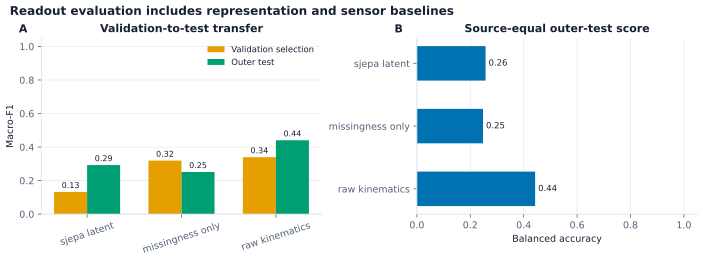

Notebook SVG: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\artifacts\real\figures\bbfm_readout_evaluation.svg
Paper assets: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_readout_evaluation.svg C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_readout_evaluation.png C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_readout_evaluation.pdf


In [10]:
# Paper and notebook rendering share this single source of truth.
from pathlib import Path as _VisualPath
import os as _visual_os
import sys as _visual_sys


def _find_visual_experiment(start=None):
    start = _VisualPath(start or _VisualPath.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "neurips-brain-body").is_dir() and (candidate / "data-gavd").is_dir():
            return candidate
        nested = candidate / "experiments" / "sjepa" / "gavd5-drift"
        if (nested / "neurips-brain-body").is_dir() and (nested / "data-gavd").is_dir():
            return nested
    raise FileNotFoundError("Could not locate experiments/sjepa/gavd5-drift")


_visual_experiment = _VisualPath(globals().get("EXPERIMENT_DIR", _find_visual_experiment())).resolve()
_visual_notebook_dir = _visual_experiment / "neurips-brain-body"
if str(_visual_notebook_dir) not in _visual_sys.path:
    _visual_sys.path.insert(0, str(_visual_notebook_dir))
try:
    from dotenv import load_dotenv as _visual_load_dotenv
    _visual_load_dotenv(_visual_experiment / ".env", override=False)
except ImportError:
    pass
_visual_mode = str(globals().get("MODE", _visual_os.getenv("GAVD_MODE", "real"))).strip().lower()
_visual_artifact_root = _VisualPath(
    _visual_os.getenv("GAVD_ARTIFACT_DIR", _visual_experiment / "work" / "artifacts")
).expanduser()
_visual_artifact_dir = _VisualPath(globals().get("ARTIFACT_DIR", _visual_artifact_root / _visual_mode))
_visual_outer_fold = int(globals().get("OUTER_FOLD", _visual_os.getenv("SJEPA_OUTER_FOLD", "0")))
_visual_seed = int(globals().get("MODEL_SEED", _visual_os.getenv("SJEPA_MODEL_SEED", "42")))
_visual_objective = str(globals().get("OBJECTIVE_NAME", _visual_os.getenv("SJEPA_OBJECTIVE", "jepa_vicreg")))

from scientific_visuals import render_notebook_summary

visual_summary = render_notebook_summary(
    "06",
    experiment_dir=_visual_experiment,
    artifact_dir=_visual_artifact_dir,
    outer_fold=_visual_outer_fold,
    model_seed=_visual_seed,
    objective=_visual_objective,
)
print("Notebook SVG:", visual_summary.notebook_svg)
print("Paper assets:", visual_summary.paper_svg, visual_summary.paper_png, visual_summary.paper_pdf)
